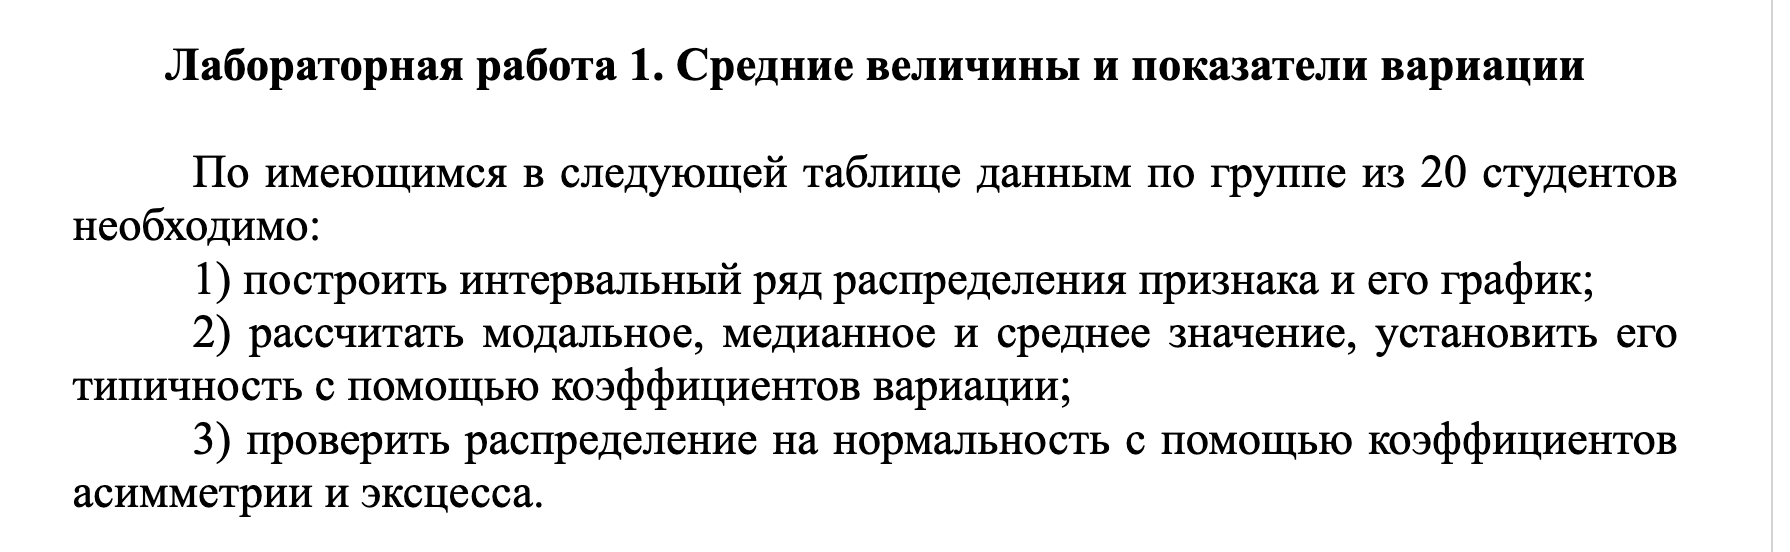

Мой Вариант: 22 mod 10 = 2

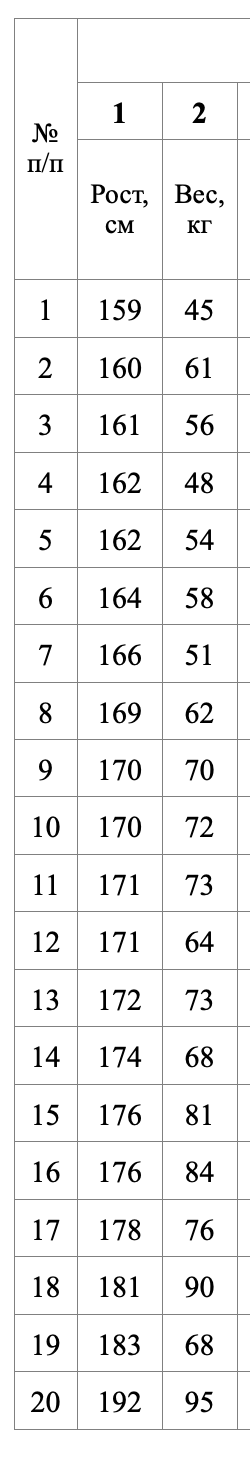

# Пункт 1

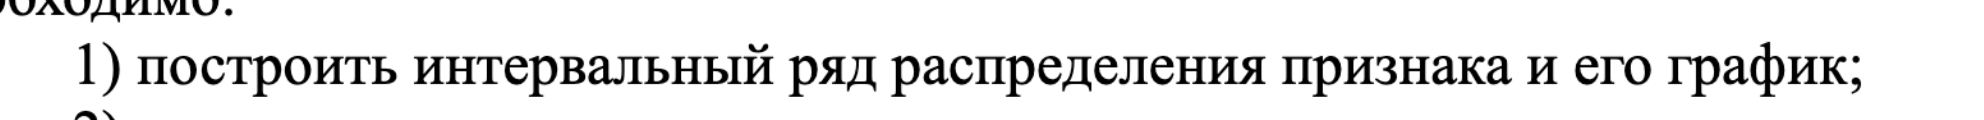


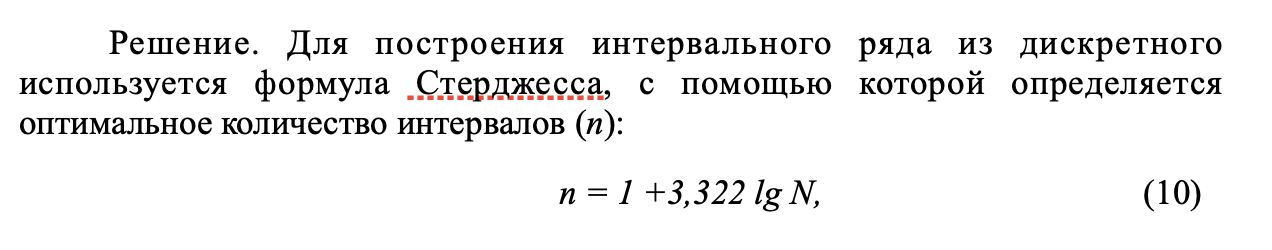

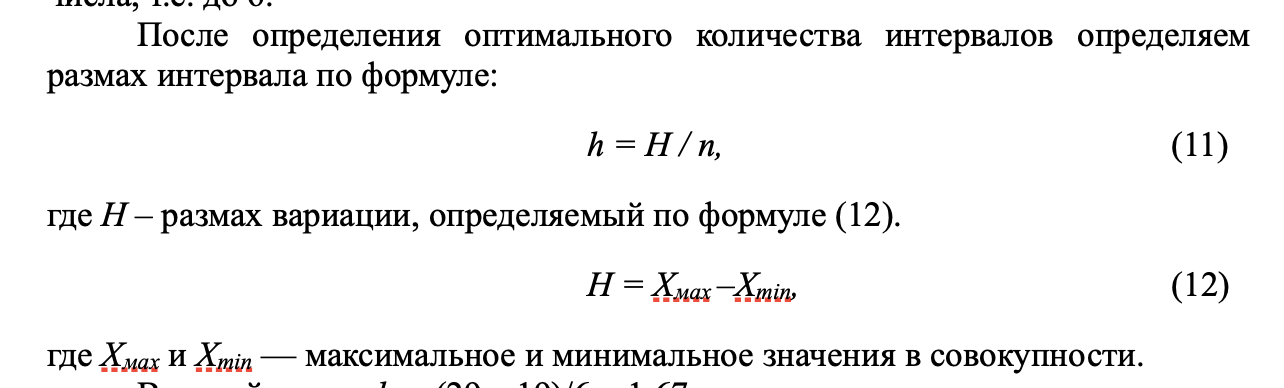

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# исходные данные
weights = [45, 61, 56, 48, 54, 58, 51, 62, 70, 72, 73, 64, 73, 68, 81, 84, 76, 90, 68, 95]
weights.sort()
print(weights)

N = len(weights)

x_min = min(weights)
x_max = max(weights)
H = x_max - x_min

n_sturges = 1 + 3.322 * np.log10(N)
n = round(n_sturges)

h = H / n

print(f"X_min: {x_min} кг")
print(f"X_max: {x_max} кг")
print(f"Размах H: {H} кг")
print(f"Число интервалов n: {n_sturges:.3f} -> округляем -> {n}")
print(f"Шаг интервала h: {h} кг")

# группируем
intervals_data = []
for i in range(n):
    lower_bound = x_min + i * h
    upper_bound = lower_bound + h
    
    if i == n - 1: # если это крайнее значение, то в правую границу
        items_in_interval = [w for w in weights if lower_bound <= w <= upper_bound] # <= and <=
    else:
        items_in_interval = [w for w in weights if lower_bound <= w < upper_bound] # <= and <
        
    intervals_data.append((lower_bound, upper_bound, items_in_interval))
# вывод
print("интервальный ряд распределения признака:")
for idx, (low, upp, items) in enumerate(intervals_data, 1):
    items_str = ", ".join(map(str, items))
    print(f"{idx}) {int(low)} – {int(upp)} кг: {len(items)} студентов ({items_str})")

print(f"имеем (\\sum f_i): {N} студентов")

[45, 48, 51, 54, 56, 58, 61, 62, 64, 68, 68, 70, 72, 73, 73, 76, 81, 84, 90, 95]
X_min: 45 кг
X_max: 95 кг
Размах H: 50 кг
Число интервалов n: 5.322 -> округляем -> 5
Шаг интервала h: 10.0 кг
интервальный ряд распределения признака:
1) 45 – 55 кг: 4 студентов (45, 48, 51, 54)
2) 55 – 65 кг: 5 студентов (56, 58, 61, 62, 64)
3) 65 – 75 кг: 6 студентов (68, 68, 70, 72, 73, 73)
4) 75 – 85 кг: 3 студентов (76, 81, 84)
5) 85 – 95 кг: 2 студентов (90, 95)
имеем (\sum f_i): 20 студентов


/var/folders/24/jr600lf178n120v25n50gtvh0000gn/T/ipykernel_8635/2450197365.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=11)


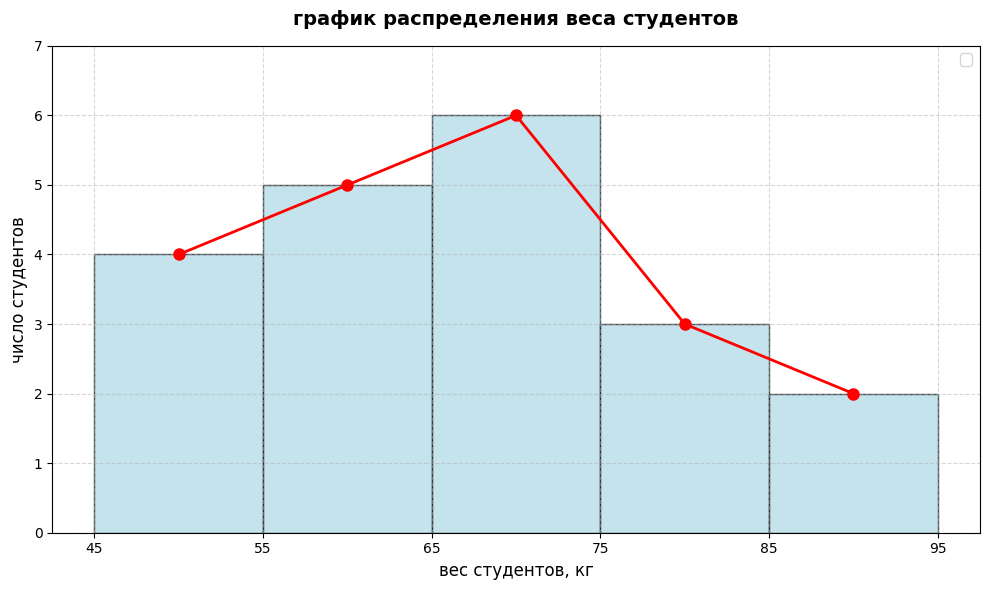

In [24]:
# ГРАФИК

# достаем 
# - границы интервалов
# - середины интервалов 
# - частоты (f_i)
bin_edges = [intervals_data[0][0]] + [inter[1] for inter in intervals_data] # все границы [45, 55, 65, 75, 85, 95]
bin_centers = [(inter[0] + inter[1]) / 2 for inter in intervals_data]      # середины X_i [50, 60, 70, 80, 90]
frequencies = [len(inter[2]) for inter in intervals_data]                  # частоты f_i [4, 5, 6, 3, 2]

plt.figure(figsize=(10, 6))

# гистограмма частот. ширина столбца равна h
plt.bar(bin_centers, frequencies, width=h, edgecolor='black', color='#add8e6', alpha=0.7)
plt.plot(bin_centers, frequencies, marker='o', color='red', linewidth=2, markersize=8)
plt.title('график распределения веса студентов', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('вес студентов, кг', fontsize=12)
plt.ylabel('число студентов', fontsize=12)

plt.xticks(bin_edges)
plt.yticks(range(0, max(frequencies) + 2))

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()


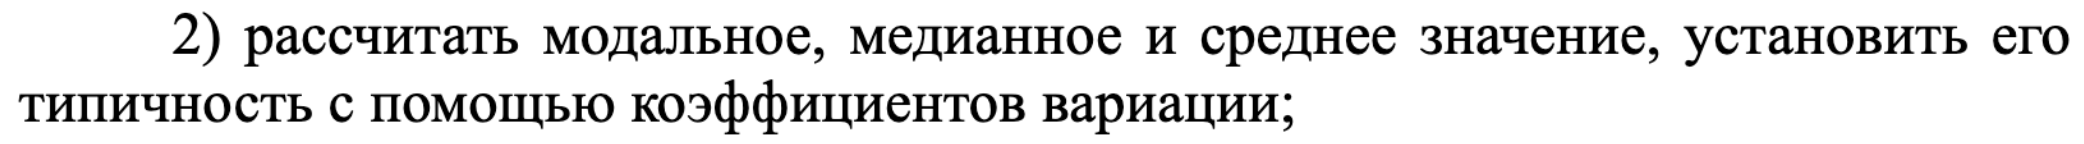

In [ ]:
f_i = [len(items) for _, _, items in intervals_data]        # частоты интервалов
X_i = [(low + upp) / 2 for low, upp, _ in intervals_data]   # середины интервалов Xi
S_cum = np.cumsum(f_i)                                      # накопленные частоты Si

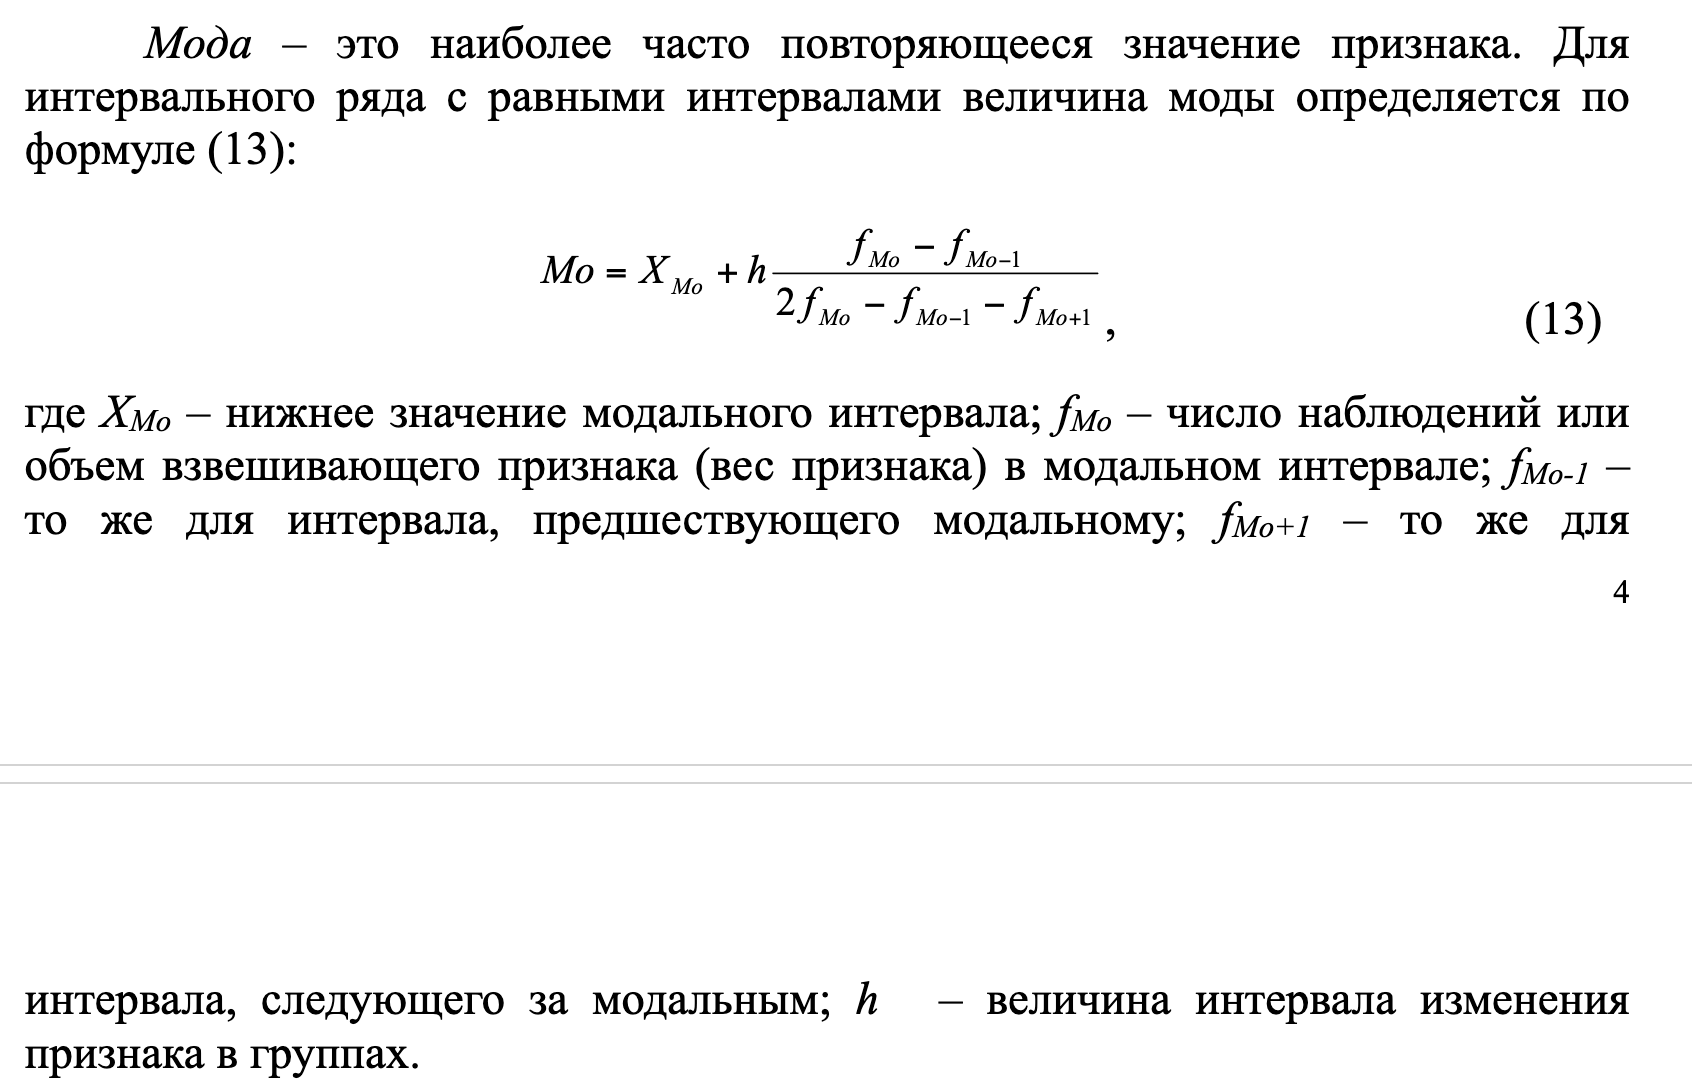

In [26]:
idx_mo = f_i.index(max(f_i))   # интервал с максимальной частотой
X_Mo = intervals_data[idx_mo][0] # нижняя граница модального интервала
f_Mo = f_i[idx_mo]
f_Mo_prev = f_i[idx_mo - 1] if idx_mo > 0 else 0
f_Mo_next = f_i[idx_mo + 1] if idx_mo < n - 1 else 0

Mo = X_Mo + h * (f_Mo - f_Mo_prev) / (2 * f_Mo - f_Mo_prev - f_Mo_next)
print(f"модальное значение: {Mo:.3f} кг")

модальное значение: 67.500 кг


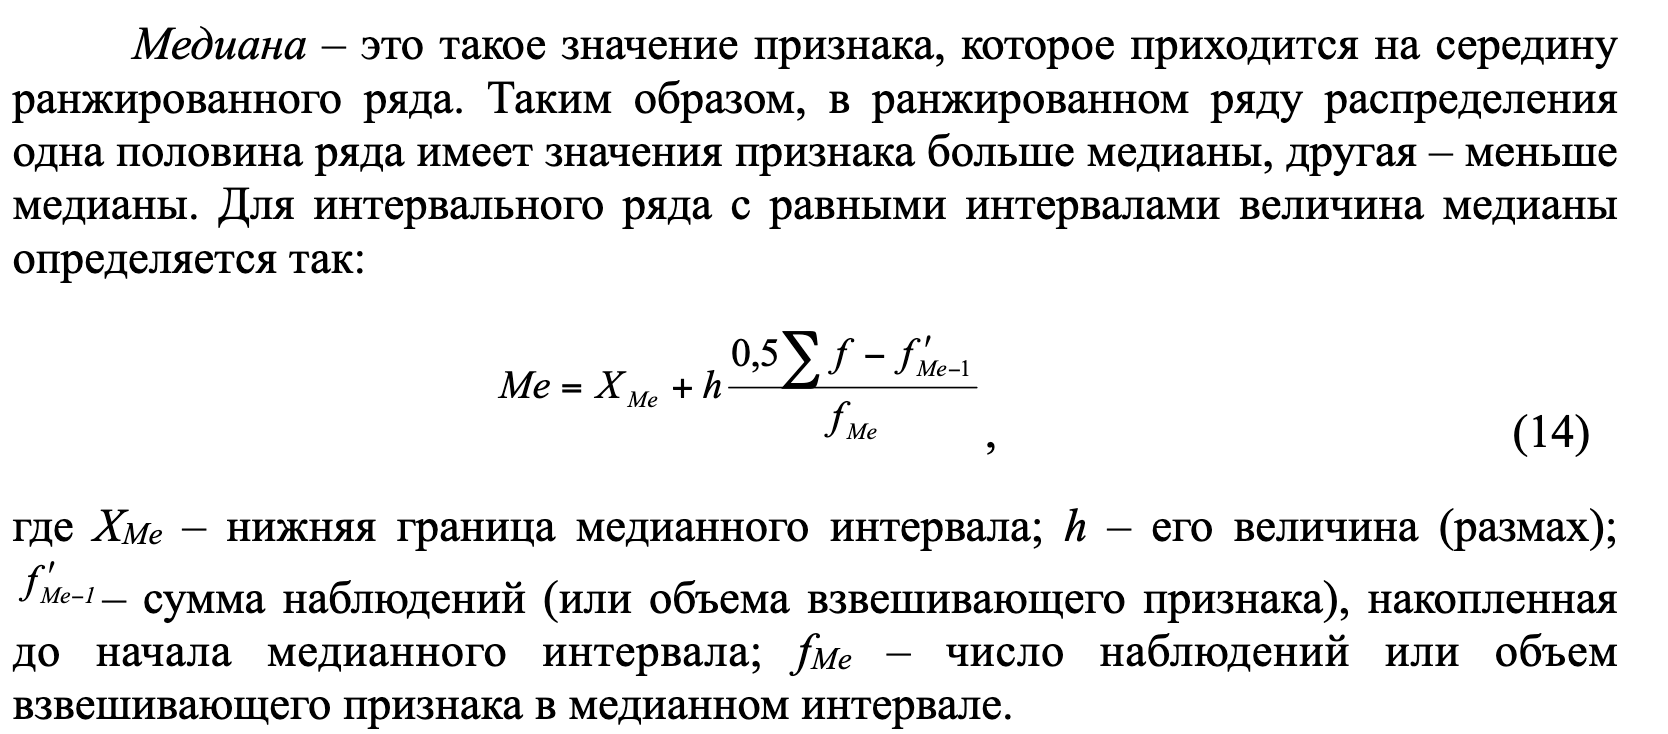

In [27]:
idx_me = int(np.where(S_cum >= N / 2)[0][0])
X_Me = intervals_data[idx_me][0] # нижняя граница медианного интервала
f_Me = f_i[idx_me]
S_Me_prev = S_cum[idx_me - 1] if idx_me > 0 else 0 # накопленная частота ДО медианного интервала

Me = X_Me + h * (0.5 * N - S_Me_prev) / f_Me
print(f"медианное значение: {Me:.3f} кг")

медианное значение: 66.667 кг


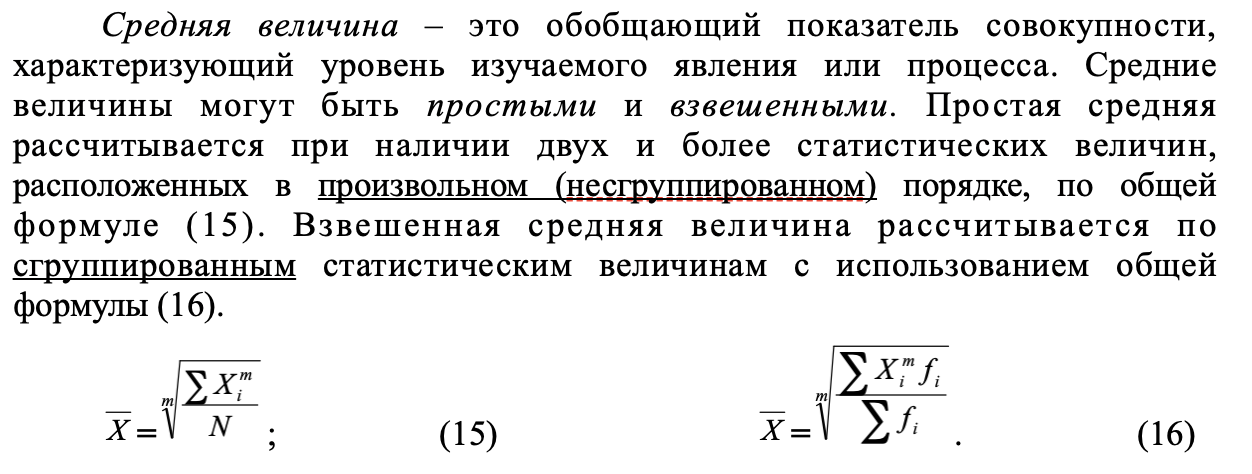

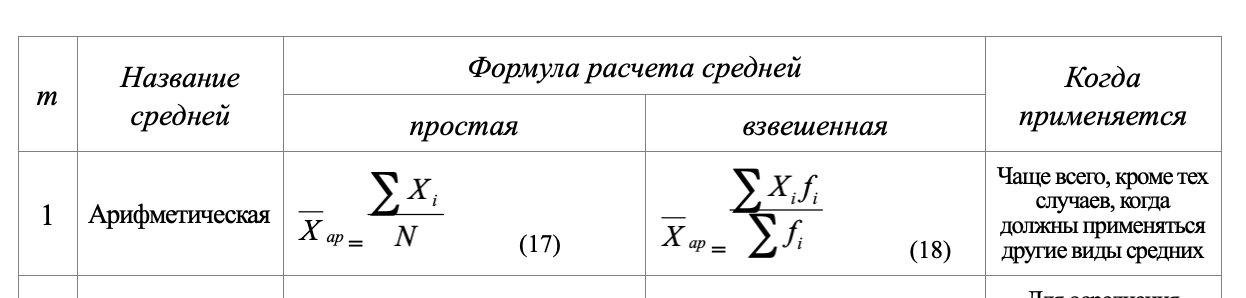

данные у нас сгрупперованны, поэтому можем использовать взвешенную

In [28]:
X_mean = sum(x * f for x, f in zip(X_i, f_i)) / N
print(f"cреднее значение: {X_mean:.3f} кг")

cреднее значение: 67.000 кг



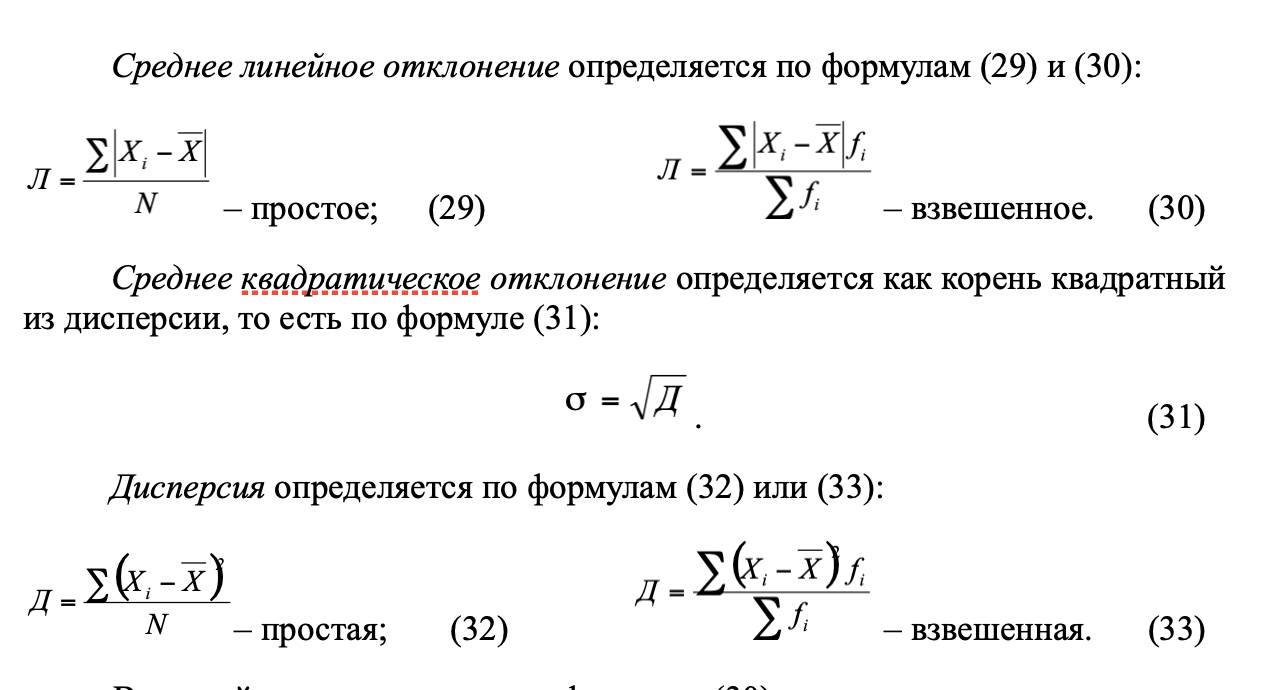

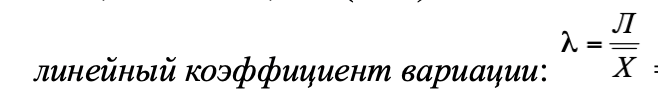

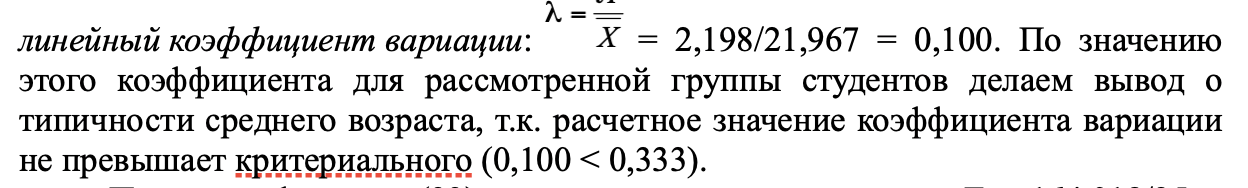

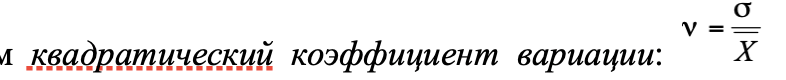

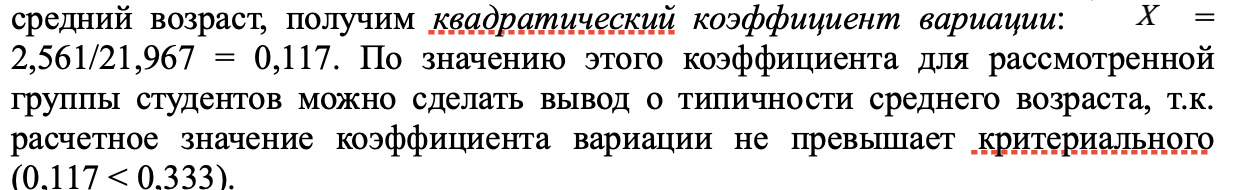

In [29]:
# среднее линейное отклонения (Л)
L_mean = sum(f * abs(x - X_mean) for x, f in zip(X_i, f_i)) / N

# линейный коэффициент вариации (lambda)
lmbda = L_mean / X_mean

# дисперсия взвешенной (Д)
variance = sum(f * (x - X_mean)**2 for x, f in zip(X_i, f_i)) / N

# среднее квадратическое отклонение (sigma)
sigma = np.sqrt(variance)

# квадратический коэффициент вариации (nu)
nu = sigma / X_mean

print(f"\nитого:")
print("-" * 55)
print(f"   - Л     : {L_mean:.3f} кг")
print(f"   - X_mean: {X_mean:.3f} кг")
print(f"   - lambda: {lmbda:.3f} ({lmbda*100:.1f}%)")
print(f"   - Д     : {variance:.3f}")
print(f"   - sigma : {sigma:.3f} кг")
print(f"   - nu.   : {nu:.3f} ({nu*100:.1f}%)")
print("-" * 55)


итого:
-------------------------------------------------------
   - Л     : 10.300 кг
   - X_mean: 67.000 кг
   - lambda: 0.154 (15.4%)
   - Д     : 151.000
   - sigma : 12.288 кг
   - nu.   : 0.183 (18.3%)
-------------------------------------------------------


по двум кэфам вариации -- является типичным 

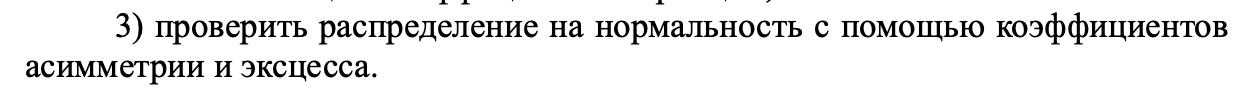

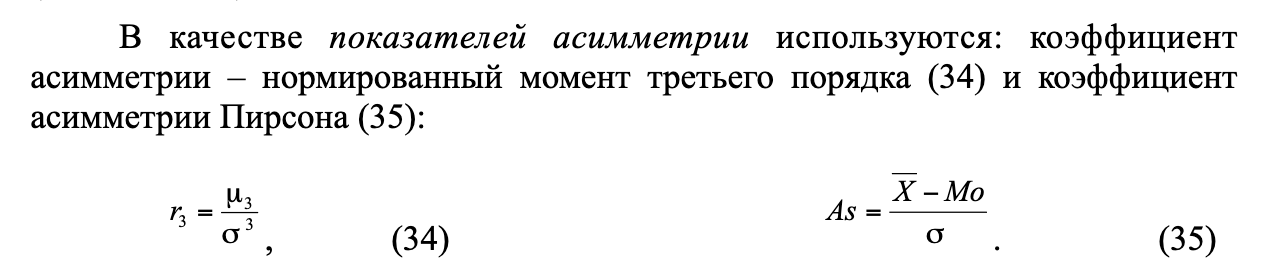

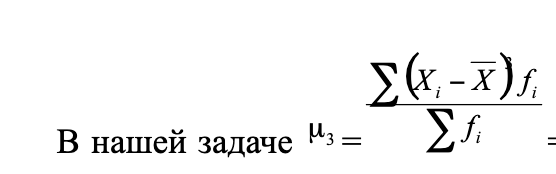

In [36]:
mu_3 = sum(f * (x - X_mean)**3 for x, f in zip(X_i, f_i)) / N
r_3 = mu_3 / (sigma**3)

As_pearson = (X_mean - Mo) / sigma

print(f"показатели асимметрии:")
print(f"   - центральный момент 3-го порядка (mu_3): {mu_3:.3f}")
print(f"   - коэффициент асимметрии (r_3)         : {r_3:.3f}")
print(f"   - коэффициент асимметрии Пирсона (As)  : {As_pearson:.3f}")

показатели асимметрии:
   - центральный момент 3-го порядка (mu_3): 486.000
   - коэффициент асимметрии (r_3)         : 0.262
   - коэффициент асимметрии Пирсона (As)  : -0.041


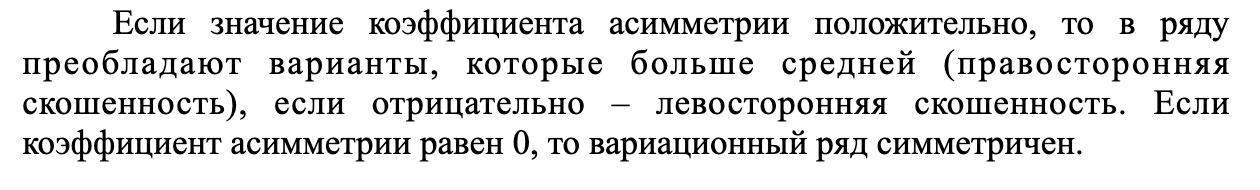

In [31]:
if r_3 > 0:
    as_desc = "правосторонней скошенностью (асимметрией)"
elif r_3 < 0:
    as_desc = "левосторонней скошенностью (асимметрией)"
else:
    as_desc = "идеальной симметрией"
print(f"   Распределение студентов по весу обладает {as_desc}.")

   Распределение студентов по весу обладает правосторонней скошенностью (асимметрией).


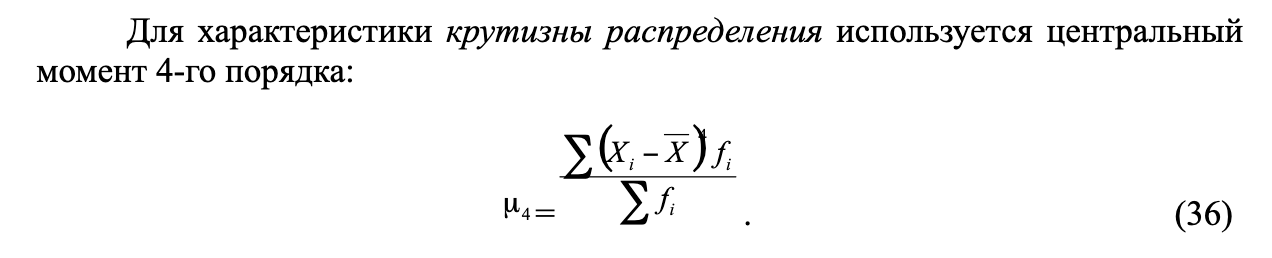

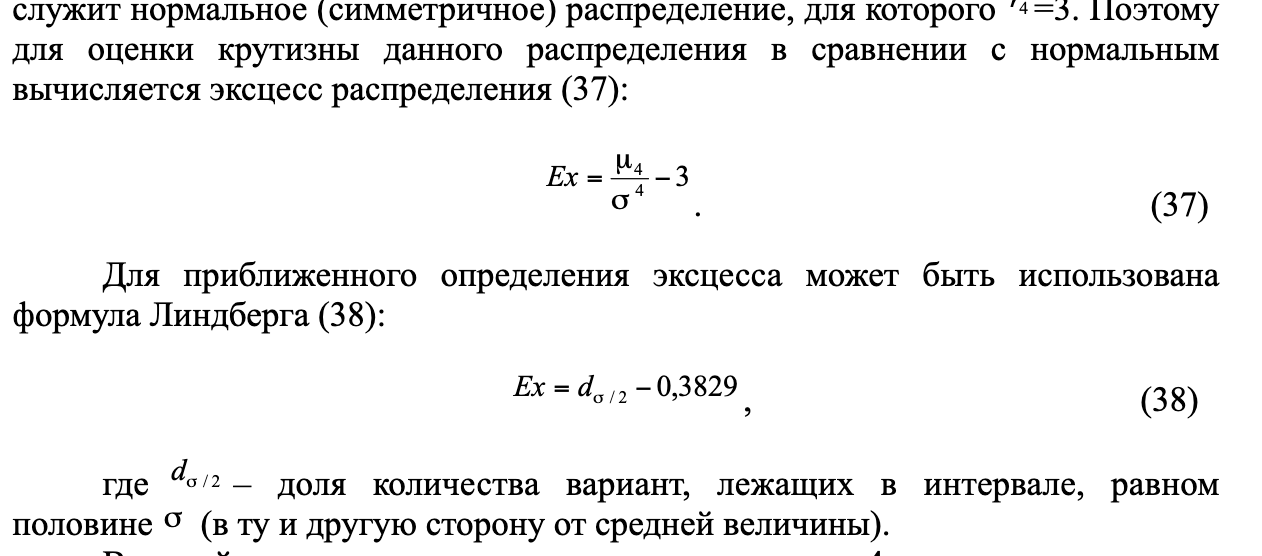

In [38]:
mu_4 = sum(f * (x - X_mean)**4 for x, f in zip(X_i, f_i)) / N
Ex = (mu_4 / (sigma**4)) - 3

print(f"\nпоказатели эксцесса:")
print(f"   - центральный момент 4-го порядка (mu_4): {mu_4:.3f}")
print(f"   - эксцесс распределения (Ex)          : {Ex:.3f}")


показатели эксцесса:
   - центральный момент 4-го порядка (mu_4): 49597.000
   - эксцесс распределения (Ex)          : -0.825


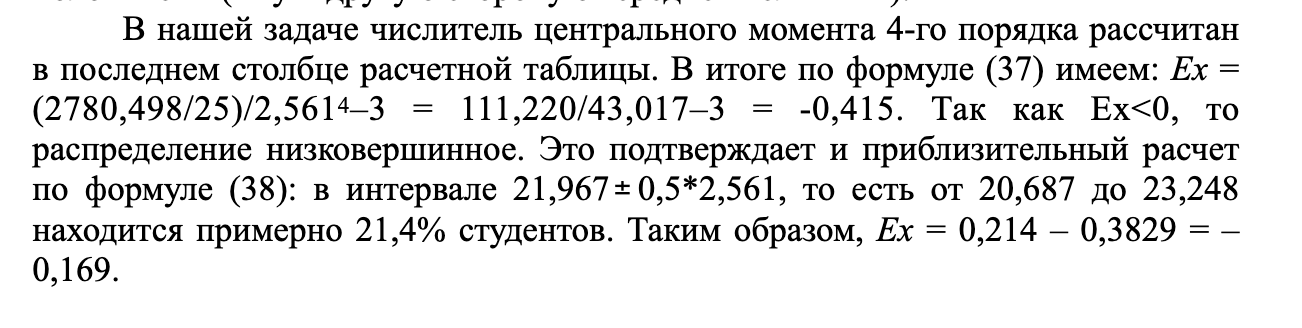

In [37]:
if Ex > 0:
    ex_desc = "островершинным (высоковершинным) по сравнению с нормальным"
elif Ex < 0:
    ex_desc = "низковершинным (плосковершинным) по сравнению с нормальным"
else:
    ex_desc = "стандартной крутизной, соответствующей нормальному"
print(f"   распределение является {ex_desc}.")


   распределение является низковершинным (плосковершинным) по сравнению с нормальным.
